In [1]:
from google.colab import files
uploaded = files.upload()

Saving user_logs.csv to user_logs.csv


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [7]:
dataset = pd.read_csv('user_logs.csv')
print(dataset)

       Username LogType  Count
0            ac   ERROR     51
1            ac    INFO     74
2       blossom   ERROR     70
3       blossom    INFO     70
4         breee   ERROR     75
5         breee    INFO     69
6     jackowens   ERROR     62
7     jackowens    INFO     63
8      mcintosh   ERROR     53
9      mcintosh    INFO     66
10     mdouglas   ERROR     47
11     mdouglas    INFO     48
12         oren   ERROR     62
13         oren    INFO     71
14  rr.robinson   ERROR     53
15  rr.robinson    INFO     66


In [9]:
dataset = dataset.pivot(index='Username', columns='LogType',values='Count').reset_index()
dataset.columns = ['Username', 'Error', 'Info']
print(dataset)

      Username  Error  Info
0           ac     51    74
1      blossom     70    70
2        breee     75    69
3    jackowens     62    63
4     mcintosh     53    66
5     mdouglas     47    48
6         oren     62    71
7  rr.robinson     53    66


In [28]:
X = dataset[['Error', 'Info']].values

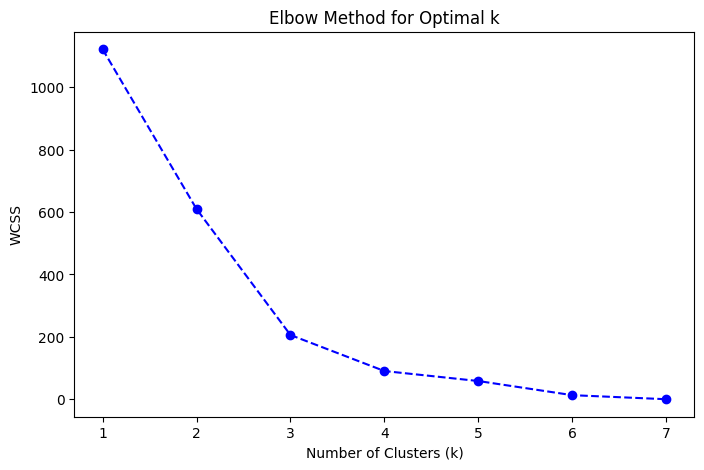

In [57]:
wcss=[]
for k in range(1,8):
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=0)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), wcss, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
# optimal number of cluster is 3

In [60]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=0)
y_kmeans = kmeans.fit_predict(X)

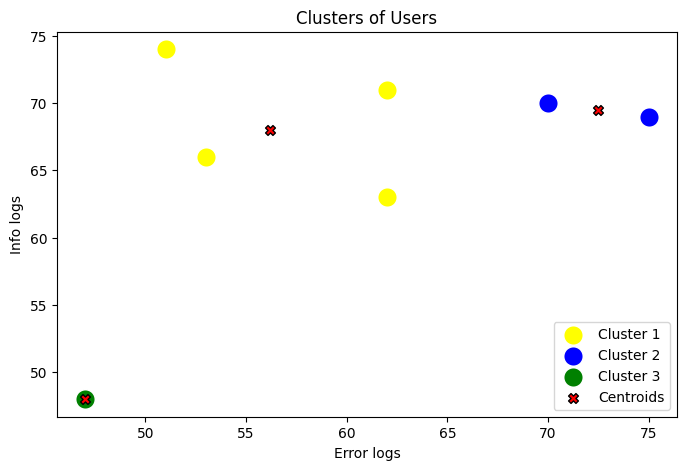

In [64]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X[y_kmeans == 0, 0], y=X[y_kmeans == 0, 1], color='yellow', label='Cluster 1', s=200)
sns.scatterplot(x=X[y_kmeans == 1, 0], y=X[y_kmeans == 1, 1], color='blue', label='Cluster 2', s=200)
sns.scatterplot(x=X[y_kmeans == 2, 0], y=X[y_kmeans == 2, 1], color = 'green', label = 'Cluster 3',s=200)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            color='red', label='Centroids', s=50, marker='X', edgecolor='black')

plt.grid(False)
plt.title('Clusters of Users')
plt.xlabel('Error logs')
plt.ylabel('Info logs')
plt.legend()
plt.show()

In [ ]:
"""The graph shows three groups of users based on their error and info logs.
   One group has more errors, meaning they might face issues often, while one
   user stands out with very low activity, which seems unusual.
"""